In [1]:
#first i imported all the necessary libraries and modules that i will need for my project.
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# read the dataset
loan_dataset=pd.read_csv('../data/loan_approval_dataset.csv')

In [3]:
#see the colomns and the rows of this dataset
loan_dataset

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [4]:
#check the missing values in the dataset
loan_dataset.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [5]:
#check the information of the dataset
loan_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   loan_id                    4269 non-null   int64
 1    no_of_dependents          4269 non-null   int64
 2    education                 4269 non-null   str  
 3    self_employed             4269 non-null   str  
 4    income_annum              4269 non-null   int64
 5    loan_amount               4269 non-null   int64
 6    loan_term                 4269 non-null   int64
 7    cibil_score               4269 non-null   int64
 8    residential_assets_value  4269 non-null   int64
 9    commercial_assets_value   4269 non-null   int64
 10   luxury_assets_value       4269 non-null   int64
 11   bank_asset_value          4269 non-null   int64
 12   loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 433.7 KB


In [6]:
#see the count, mean, std, min, max, and other statistical measures of the dataset
loan_dataset.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [7]:
#check for duplicate rows in the dataset
loan_dataset.duplicated().sum()

np.int64(0)

In [8]:
#see columns names of the dataset
loan_dataset.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='str')

In [9]:
#split the dataset into featuers and target variable
#target variable is the last column of the dataset which is 'Loan_Status' and the features are all the other columns
features = loan_dataset.iloc[:, :-1]
target=loan_dataset.iloc[:, -1]
print(features.head(5))
print(target.head(5))

   loan_id   no_of_dependents      education  self_employed   income_annum  \
0        1                  2       Graduate             No        9600000   
1        2                  0   Not Graduate            Yes        4100000   
2        3                  3       Graduate             No        9100000   
3        4                  3       Graduate             No        8200000   
4        5                  5   Not Graduate            Yes        9800000   

    loan_amount   loan_term   cibil_score   residential_assets_value  \
0      29900000          12           778                    2400000   
1      12200000           8           417                    2700000   
2      29700000          20           506                    7100000   
3      30700000           8           467                   18200000   
4      24200000          20           382                   12400000   

    commercial_assets_value   luxury_assets_value   bank_asset_value  
0                  17600000

In [10]:
# Define the numerical and categorical features
num_features = ['loan_id', ' no_of_dependents', ' loan_amount', ' cibil_score',' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value']
cat_features = [' education',' self_employed']

In [11]:
# Create the preprocessing piplines for both numerical and cat features
num_transformer=StandardScaler()
cat_transformer = OneHotEncoder(handle_unknown='ignore')

In [12]:
# combibne the numerical and categorical transformers into a single preprocessor using ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

<Axes: ylabel=' education'>

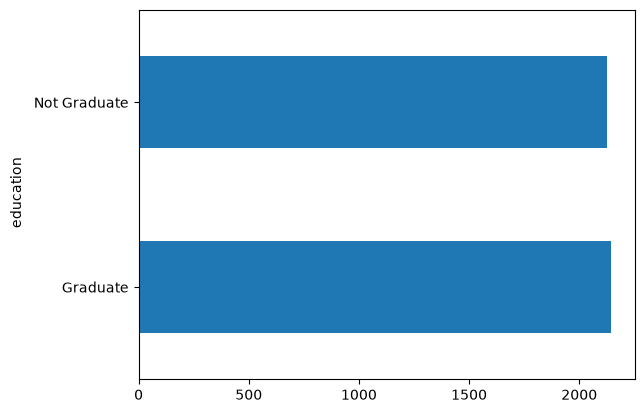

In [13]:
#visulizing the distribution of the education feature
features[" education"].value_counts().plot(kind='barh')

<Axes: ylabel=' self_employed'>

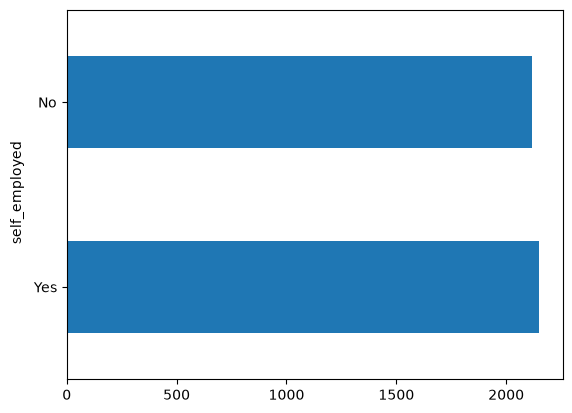

In [14]:
#visulizing the distribution of the self_employed feature
features[" self_employed"].value_counts().plot(kind='barh')

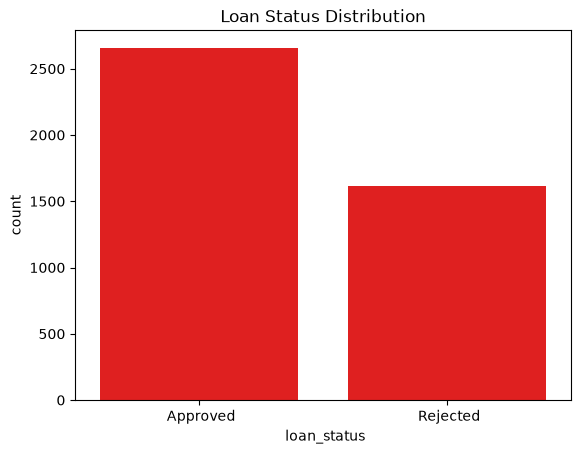

In [15]:
#visulizing the distribution of the loan status target
sns.countplot(data=loan_dataset, x=" loan_status", color="red")
plt.title("Loan Status Distribution")
plt.show()

In [16]:
#i assigned the feature with x and target with y
X=  features
y= loan_dataset[' loan_status']

In [17]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (3415, 12)
Testing set shape: (854, 12)


In [19]:
# Create a pipeline that combines the preprocessor and the classifier
pipeline = Pipeline([
    ('preprocessor', preprocessor),  # Data transformation
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))  # ML model
])

In [20]:
# Fit the pipeline to the training data
pipeline.fit(X_train, y_train)
print("Model training complete!")

Model training complete!


In [21]:
#predict the target variable for the test set
y_pred_RF = pipeline.predict(X_test)

In [22]:
# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred_RF)
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 0.96


In [23]:
# Print the classification report
print(classification_report(y_test, y_pred_RF))

              precision    recall  f1-score   support

    Approved       1.00      0.93      0.96       536
    Rejected       0.90      1.00      0.94       318

    accuracy                           0.96       854
   macro avg       0.95      0.96      0.95       854
weighted avg       0.96      0.96      0.96       854



In [24]:
# see the first five rows of the actual and predicted values
predictions = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_RF })
print(predictions.head())

         Actual  Predicted
1703   Rejected   Rejected
1173   Approved   Approved
308    Rejected   Rejected
1322   Approved   Approved
3271   Approved   Approved


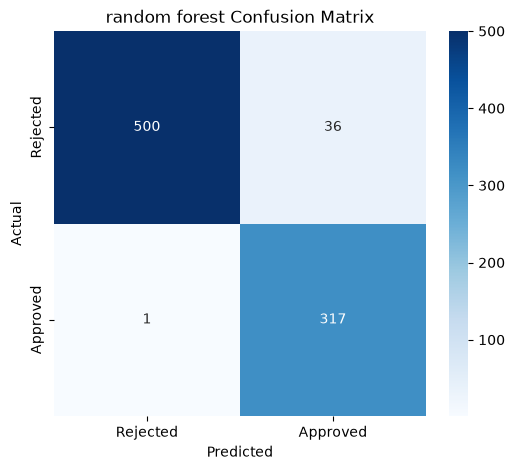

In [25]:
# Create a confusion matrix to visualize the performance of the model
cm = confusion_matrix(y_test, y_pred_RF)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Rejected','Approved'],
            yticklabels=['Rejected','Approved'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("random forest Confusion Matrix")
plt.show()

In [26]:
# Create a new pipline with logistic regression 
pipeline_log = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])


In [27]:
# fit the logistic pipline to the training data
pipeline_log.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","[' Approved',' Rejected']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['loan_id',' no_of_dependents',' education',...,' commercial_assets_value', ' luxury_assets_value',' bank_asset_value']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are droppe

In [28]:
#predict the target variable for the test set using logistic regression
y_pred_log = pipeline_log.predict(X_test)

In [29]:
# see the accuracy of the logistic regression model
print("Accuracy:", accuracy_score(y_test, y_pred_log))

Accuracy: 0.927400468384075


In [30]:
# Print the classification report for logistic regression
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

    Approved       0.95      0.94      0.94       536
    Rejected       0.90      0.91      0.90       318

    accuracy                           0.93       854
   macro avg       0.92      0.92      0.92       854
weighted avg       0.93      0.93      0.93       854



In [31]:
# compare the actual and predicted values for logistic regression
predictions = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_log})
print(predictions.head())

         Actual  Predicted
1703   Rejected   Rejected
1173   Approved   Approved
308    Rejected   Rejected
1322   Approved   Approved
3271   Approved   Approved


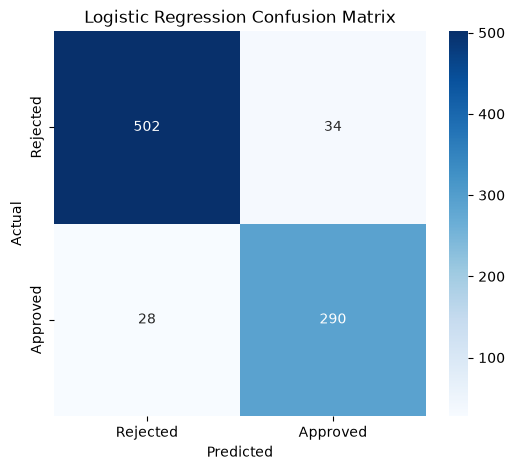

In [32]:
# Create a confusion matrix to visualize the performance 
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Rejected','Approved'],
            yticklabels=['Rejected','Approved'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [33]:
# between the two models, the random forest classifier has a higher accuracy and better performance metrics compared to the logistic regression model. Therefore, the random forest classifier is the better model for this loan approval classification task.